# Interpret whole-slide clinical predictions

Run released clinical models, map tile-level scores to tissue and analyze patient-level prognostic risk.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e ".[clinical]"
python -m pip install jupyter ipywidgets numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = (
    Path(configured_data).expanduser()
    if configured_data
    else Path("data")
)
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

np.random.seed(0)
sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 135,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})

## Overview

Use the public HistAgent clinical API to run trained ABMIL models on HistAgent tile representations, compare annotated tissue regions and calculate patient-level prognostic risk.

In [2]:
from histagent.clinical import HistAgentClinical

clinical_model = HistAgentClinical.from_data_dir(DATA_DIR)
survival = pd.read_csv(DATA_DIR / "figure4_survival_oof.csv")
reported = pd.read_json(DATA_DIR / "fig4d_summary.json")

print(f"Clinical examples: {len(clinical_model.case_metadata)}")
print(f"Out-of-fold patients: {survival['case_id'].nunique():,}")

Clinical examples: 3
Out-of-fold patients: 842


## Run clinical inference

Calling the clinical model loads the released HistAgent tile representations and trained ABMIL checkpoints, then calculates tile scores and attention weights for each slide.

In [3]:
predictions = clinical_model()
case_summary = clinical_model.case_summary(predictions)
case_summary

,cohort,case,tiles,annotated_tiles,models
0,STAD,TCGA-VQ-AA6B,73724,28679,5
1,STAD,TCGA-BR-8486,77760,62494,5
2,BRCA,TCGA-E2-A1LH,75260,145,1


## Compare annotated tissue regions

The same calculated tile scores are used for the spatial maps and the region-level tests. STAD compares poorly and highly differentiated tissue; BRCA compares tumor and stroma within the annotated ROI.

In [4]:
region_tests = clinical_model.compare_regions(predictions)
region_tests

,cohort,case,comparison,n_1,n_2,Mann–Whitney P
0,STAD,TCGA-VQ-AA6B,Poor > High,28361,318,3.835881e-86
1,STAD,TCGA-BR-8486,Poor > High,52382,10112,0.000000e+00
2,BRCA,TCGA-E2-A1LH,Tumor > Stroma,79,66,6.375774e-12


## Spatial visualization of clinical scores

Map the calculated tile scores back to the two STAD whole-slide examples.

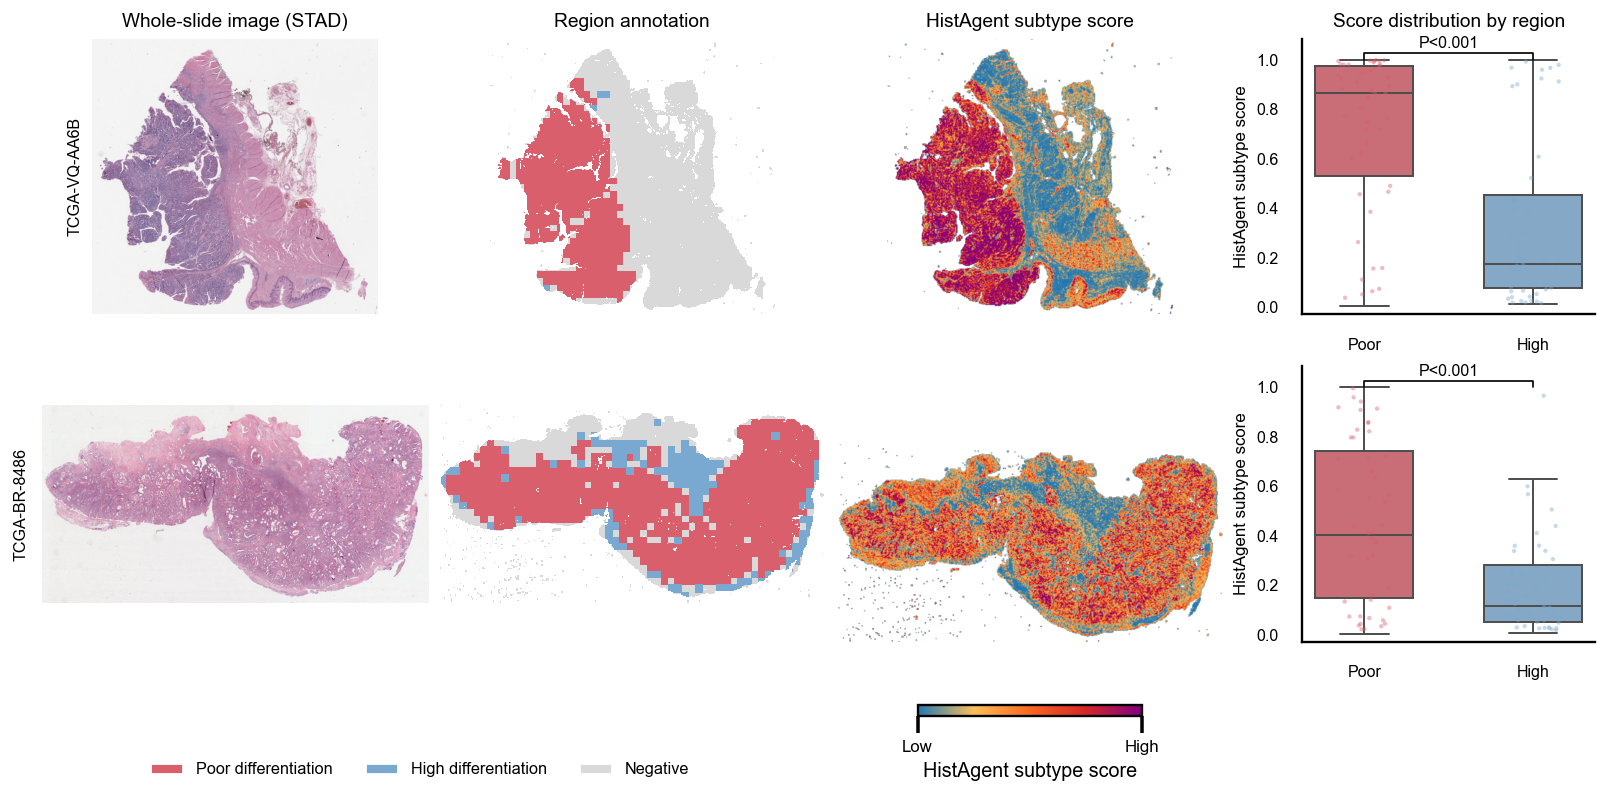

In [5]:
stad_figure = clinical_model.plot_stad(
    predictions,
    region_tests,
)
plt.show()

### Overall-survival risk within a breast-cancer ROI

The H&E crop, tissue annotation and risk field use the same ROI in the original whole-slide coordinate system.

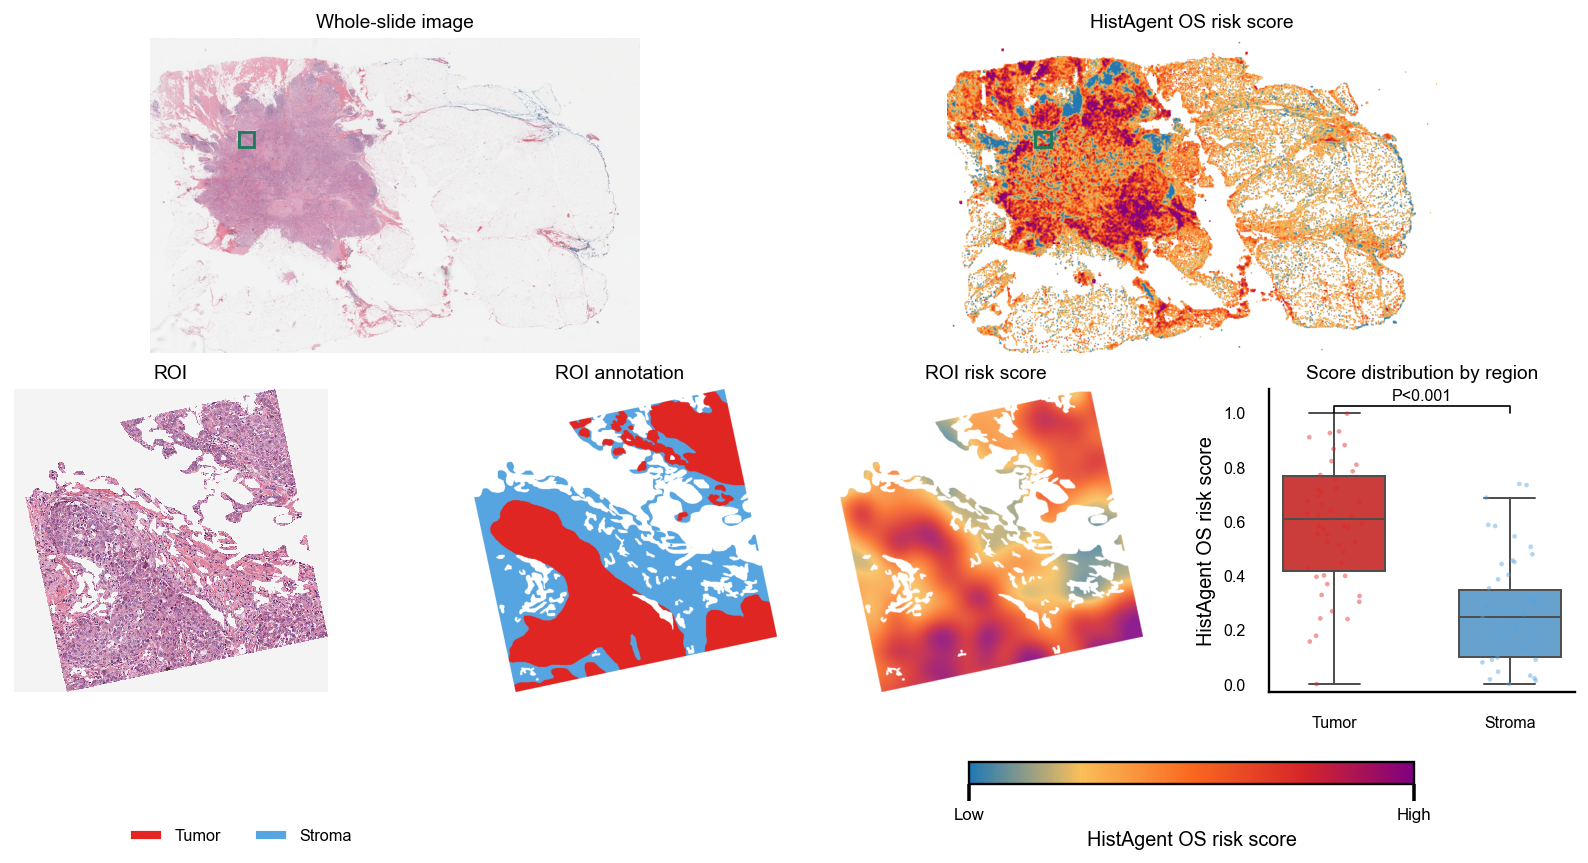

In [6]:
brca_figure = clinical_model.plot_brca(
    predictions,
    region_tests,
)
plt.show()

## Patient-level prognostic-risk stratification

Patients are split at the cohort-specific median out-of-fold risk. The model API calculates the Kaplan–Meier curves and log-rank p-values.

In [7]:
survival_analysis = clinical_model.analyze_survival(
    survival,
    reported,
)
survival_analysis.metrics.round(3)

,Cohort,C-index,Log-rank P
0,LGG,0.749,0.0
1,LIHC,0.742,0.0


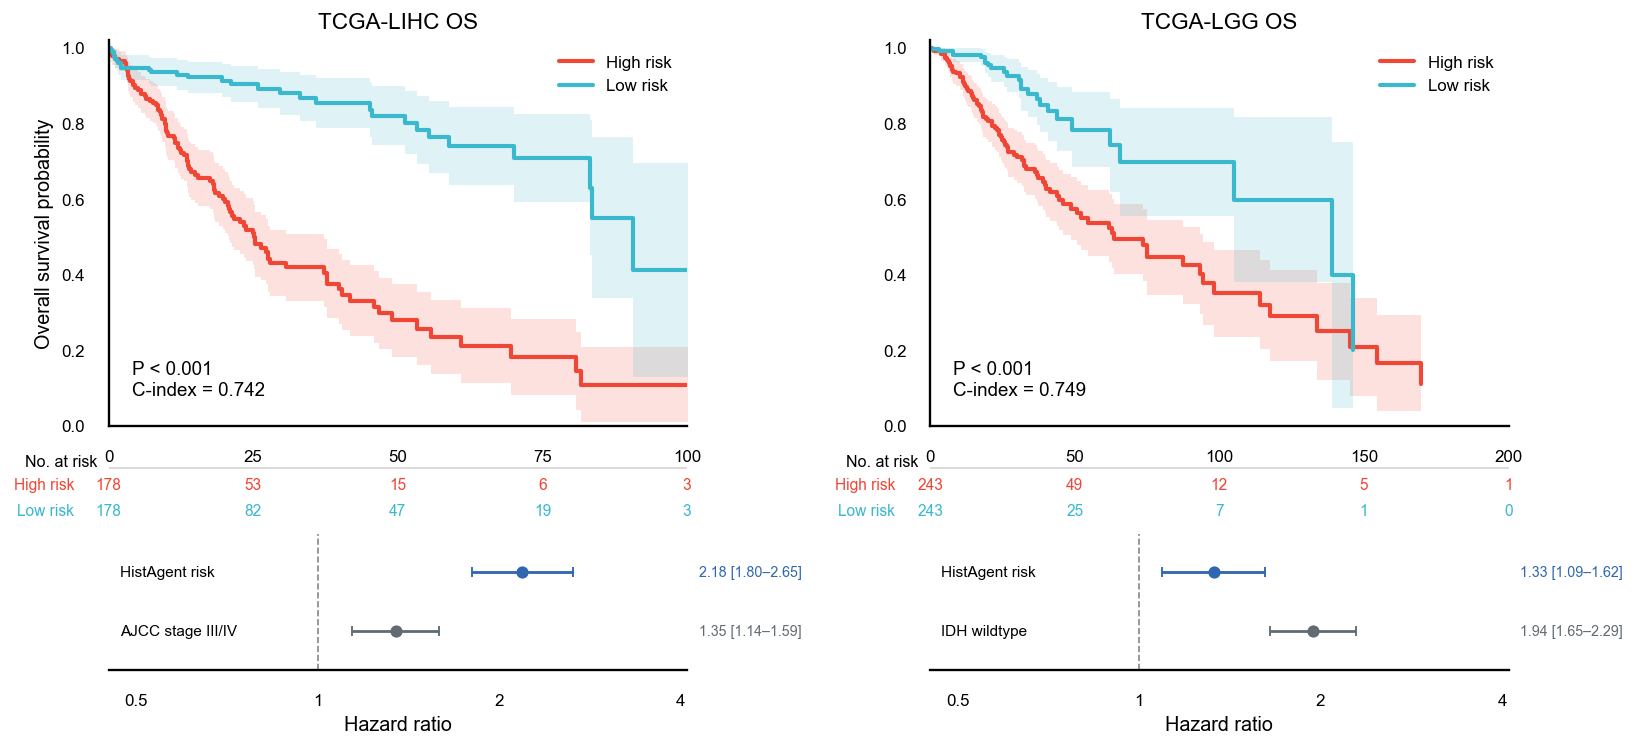

In [8]:
survival_figure = clinical_model.plot_survival(
    survival_analysis
)
plt.show()

## Multivariable prognostic analysis

HistAgent risk is entered per standard deviation together with the cohort-specific clinical covariate.

In [9]:
forest_table = survival_analysis.cox.rename(columns={
    "cohort": "Cohort",
    "quantity_or_covariate": "Covariate",
    "hazard_ratio": "Hazard ratio",
}).copy()
forest_table["95% CI"] = forest_table.apply(
    lambda row: f"{row['ci_low']:.2f}–{row['ci_high']:.2f}",
    axis=1,
)
forest_table[
    ["Cohort", "Covariate", "Hazard ratio", "95% CI"]
]

,Cohort,Covariate,Hazard ratio,95% CI
5,LIHC,HistAgent risk per 1 SD,2.18,1.80–2.65
6,LIHC,AJCC stage III/IV,1.35,1.14–1.59
12,LGG,HistAgent risk per 1 SD,1.33,1.09–1.62
13,LGG,IDH wildtype,1.94,1.65–2.29


## Verify the calculations

In [10]:
assert len(clinical_model.case_metadata) == 3
assert set(predictions.tiles["cohort"]) == {"STAD", "BRCA"}
assert predictions.tiles.groupby("case").size().min() > 70_000
assert len(region_tests) == 3
assert np.isfinite(region_tests["Mann–Whitney P"]).all()
assert not survival_analysis.patients["case_id"].duplicated().any()
assert set(survival_analysis.patients["cohort"]) == {"LIHC", "LGG"}
assert {
    cohort: len(frame)
    for cohort, frame in survival_analysis.patients.groupby("cohort")
} == {"LIHC": 356, "LGG": 486}
print("Checks passed for clinical inference, region tests and survival analysis.")

Checks passed for clinical inference, region tests and survival analysis.


## Continue

Continue to **ST atlas retrieval** to visualize the spatial transcriptomics atlas and run natural-language and H&E image queries.